[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train YOLO11 Object Detection on a Custom Dataset

---

[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/ultralytics/ultralytics)

YOLO11 builds on the advancements introduced in YOLOv9 and YOLOv10 earlier this year, incorporating improved architectural designs, enhanced feature extraction techniques, and optimized training methods.

YOLO11m achieves a higher mean mAP score on the COCO dataset while using 22% fewer parameters than YOLOv8m, making it computationally lighter without sacrificing performance.

YOLOv11 is available in 5 different sizes, ranging from `2.6M` to `56.9M` parameters, and capable of achieving from `39.5` to `54.7` mAP on the COCO dataset.

## Setup

### Configure API keys

To fine-tune YOLO11, you need to provide your Roboflow API key. Follow these steps:

- Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑). Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

### Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [ ]:
!nvidia-smi

Wed Nov  5 17:00:18 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install YOLO11 via Ultralytics

In [ ]:
%pip install "ultralytics<=8.3.40" supervision roboflow
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 39.3/235.7 GB disk)


## Inference with model pre-trained on COCO dataset

### CLI

**NOTE:** CLI requires no customization or Python code. You can simply run all tasks from the terminal with the yolo command.

In [ ]:
!yolo task=detect mode=predict model=yolo11n.pt conf=0.25 source='https://media.roboflow.com/notebooks/examples/dog.jpeg' save=True

100% 5.35M/5.35M [00:00<00:00, 228MB/s]
Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

100% 104k/104k [00:00<00:00, 61.2MB/s]
image 1/1 /content/dog.jpeg: 640x384 2 persons, 1 car, 1 dog, 1 handbag, 47.9ms
Speed: 5.9ms preprocess, 47.9ms inference, 241.9ms postprocess per image at shape (1, 3, 640, 384)
Results saved to runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


**NOTE:** Result annotated image got saved in `{HOME}/runs/detect/predict/`. Let's display it.

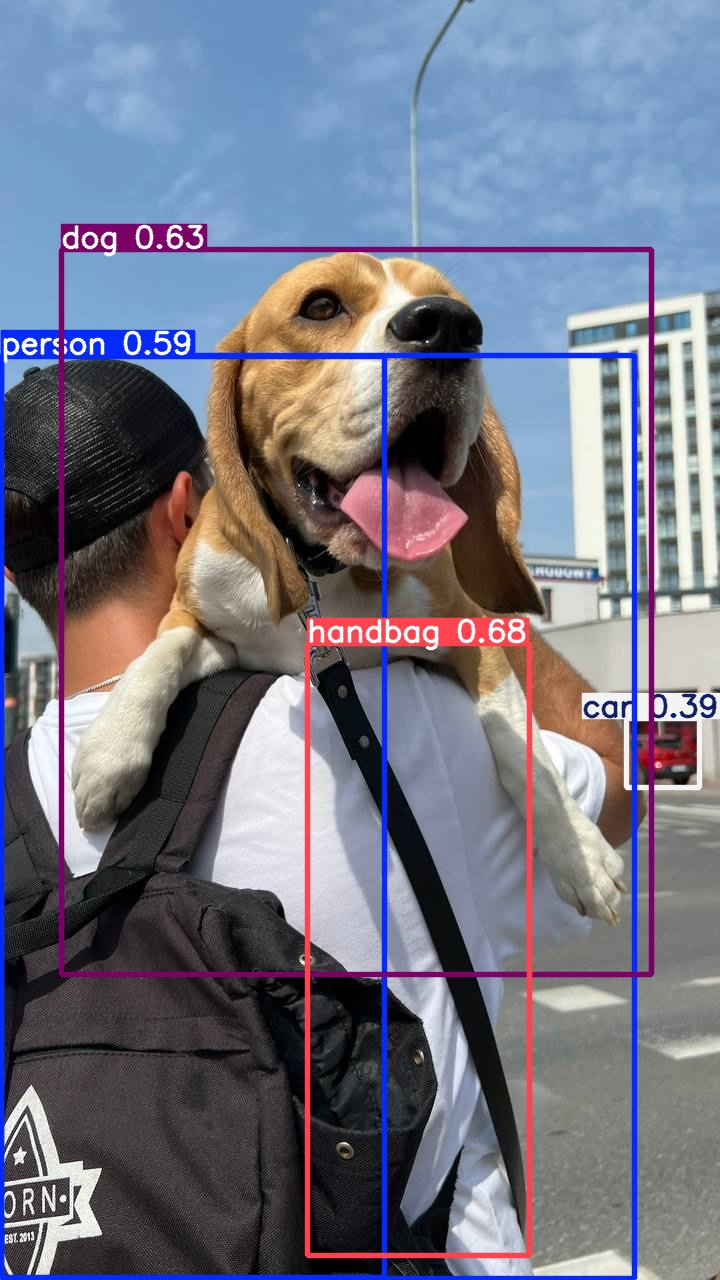

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/predict/dog.jpg', width=600)

### SDK

**NOTE:** YOLO's Python interface allows for seamless integration into your Python projects, making it easy to load, run, and process the model's output.

In [ ]:
from ultralytics import YOLO
from PIL import Image
import requests

model = YOLO('yolo11n.pt')
image = Image.open(requests.get('https://media.roboflow.com/notebooks/examples/dog.jpeg', stream=True).raw)
result = model.predict(image, conf=0.25)[0]


0: 640x384 2 persons, 1 car, 1 dog, 1 handbag, 52.8ms
Speed: 3.4ms preprocess, 52.8ms inference, 75.3ms postprocess per image at shape (1, 3, 640, 384)


**NOTE:** The obtained `result` object stores information about the location, classes, and confidence levels of the detected objects.

In [ ]:
result.boxes.xyxy

tensor([[3.0705e+02, 6.4341e+02, 5.2919e+02, 1.2558e+03],
        [6.1400e+01, 2.4994e+02, 6.5165e+02, 9.7412e+02],
        [1.7803e+00, 3.5551e+02, 6.3404e+02, 1.2788e+03],
        [1.1933e+00, 3.5620e+02, 3.8455e+02, 1.2776e+03],
        [6.2615e+02, 7.1818e+02, 6.9975e+02, 7.8754e+02]], device='cuda:0')

In [ ]:
result.boxes.conf

tensor([0.6832, 0.6284, 0.5941, 0.3923, 0.3875], device='cuda:0')

In [ ]:
result.boxes.cls

tensor([26., 16.,  0.,  0.,  2.], device='cuda:0')

**NOTE:** YOLO11 can be easily integrated with `supervision` using the familiar `from_ultralytics` connector.

In [ ]:
import supervision as sv

detections = sv.Detections.from_ultralytics(result)

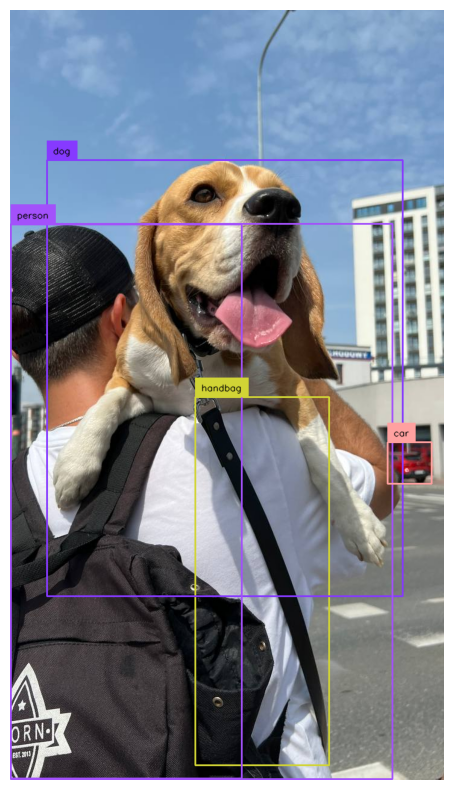

In [ ]:
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator(text_color=sv.Color.BLACK)

annotated_image = image.copy()
annotated_image = box_annotator.annotate(annotated_image, detections=detections)
annotated_image = label_annotator.annotate(annotated_image, detections=detections)

sv.plot_image(annotated_image, size=(10, 10))

## Fine-tune YOLO11 on custom dataset

**NOTE:** When training YOLOv11, make sure your data is located in `datasets`. If you'd like to change the default location of the data you want to use for fine-tuning, you can do so through Ultralytics' `settings.json`. In this tutorial, we will use one of the [datasets](https://universe.roboflow.com/liangdianzhong/-qvdww) available on [Roboflow Universe](https://universe.roboflow.com/). When downloading, make sure to select the `yolov11` export format.

In [ ]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

from roboflow import Roboflow
rf = Roboflow(api_key="")
project = rf.workspace("").project("face_emotion_recognition-fer2025_ml_project_uiu_spring2025")
version = project.version(8)
dataset = version.download("yolov11")

/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Face_Emotion_Recognition-(fer2025_ml_project_uiu_spring2025)-8 in yolov11:: 100%|██████████| 14784/14784 [00:01<00:00, 8642.58it/s]


## Custom Training

In [ ]:
%cd {HOME}

!yolo task=detect mode=train model=yolo11s.pt data=/content/datasets/FER2025/data.yaml epochs=50 imgsz=640 plots=True

/content
100% 18.4M/18.4M [00:00<00:00, 390MB/s]
New https://pypi.org/project/ultralytics/8.3.225 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/content/datasets/FER2025/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=Non

**NOTE:** The results of the completed training are saved in `{HOME}/runs/detect/train/`. Let's examine them.

In [ ]:
!ls {HOME}/runs/detect/train/

args.yaml					    train_batch12960.jpg
confusion_matrix_normalized.png			    train_batch12961.jpg
confusion_matrix.png				    train_batch12962.jpg
events.out.tfevents.1762362192.f4935f3419a7.1630.0  train_batch1.jpg
F1_curve.png					    train_batch2.jpg
labels_correlogram.jpg				    val_batch0_labels.jpg
labels.jpg					    val_batch0_pred.jpg
P_curve.png					    val_batch1_labels.jpg
PR_curve.png					    val_batch1_pred.jpg
R_curve.png					    val_batch2_labels.jpg
results.csv					    val_batch2_pred.jpg
results.png					    weights
train_batch0.jpg


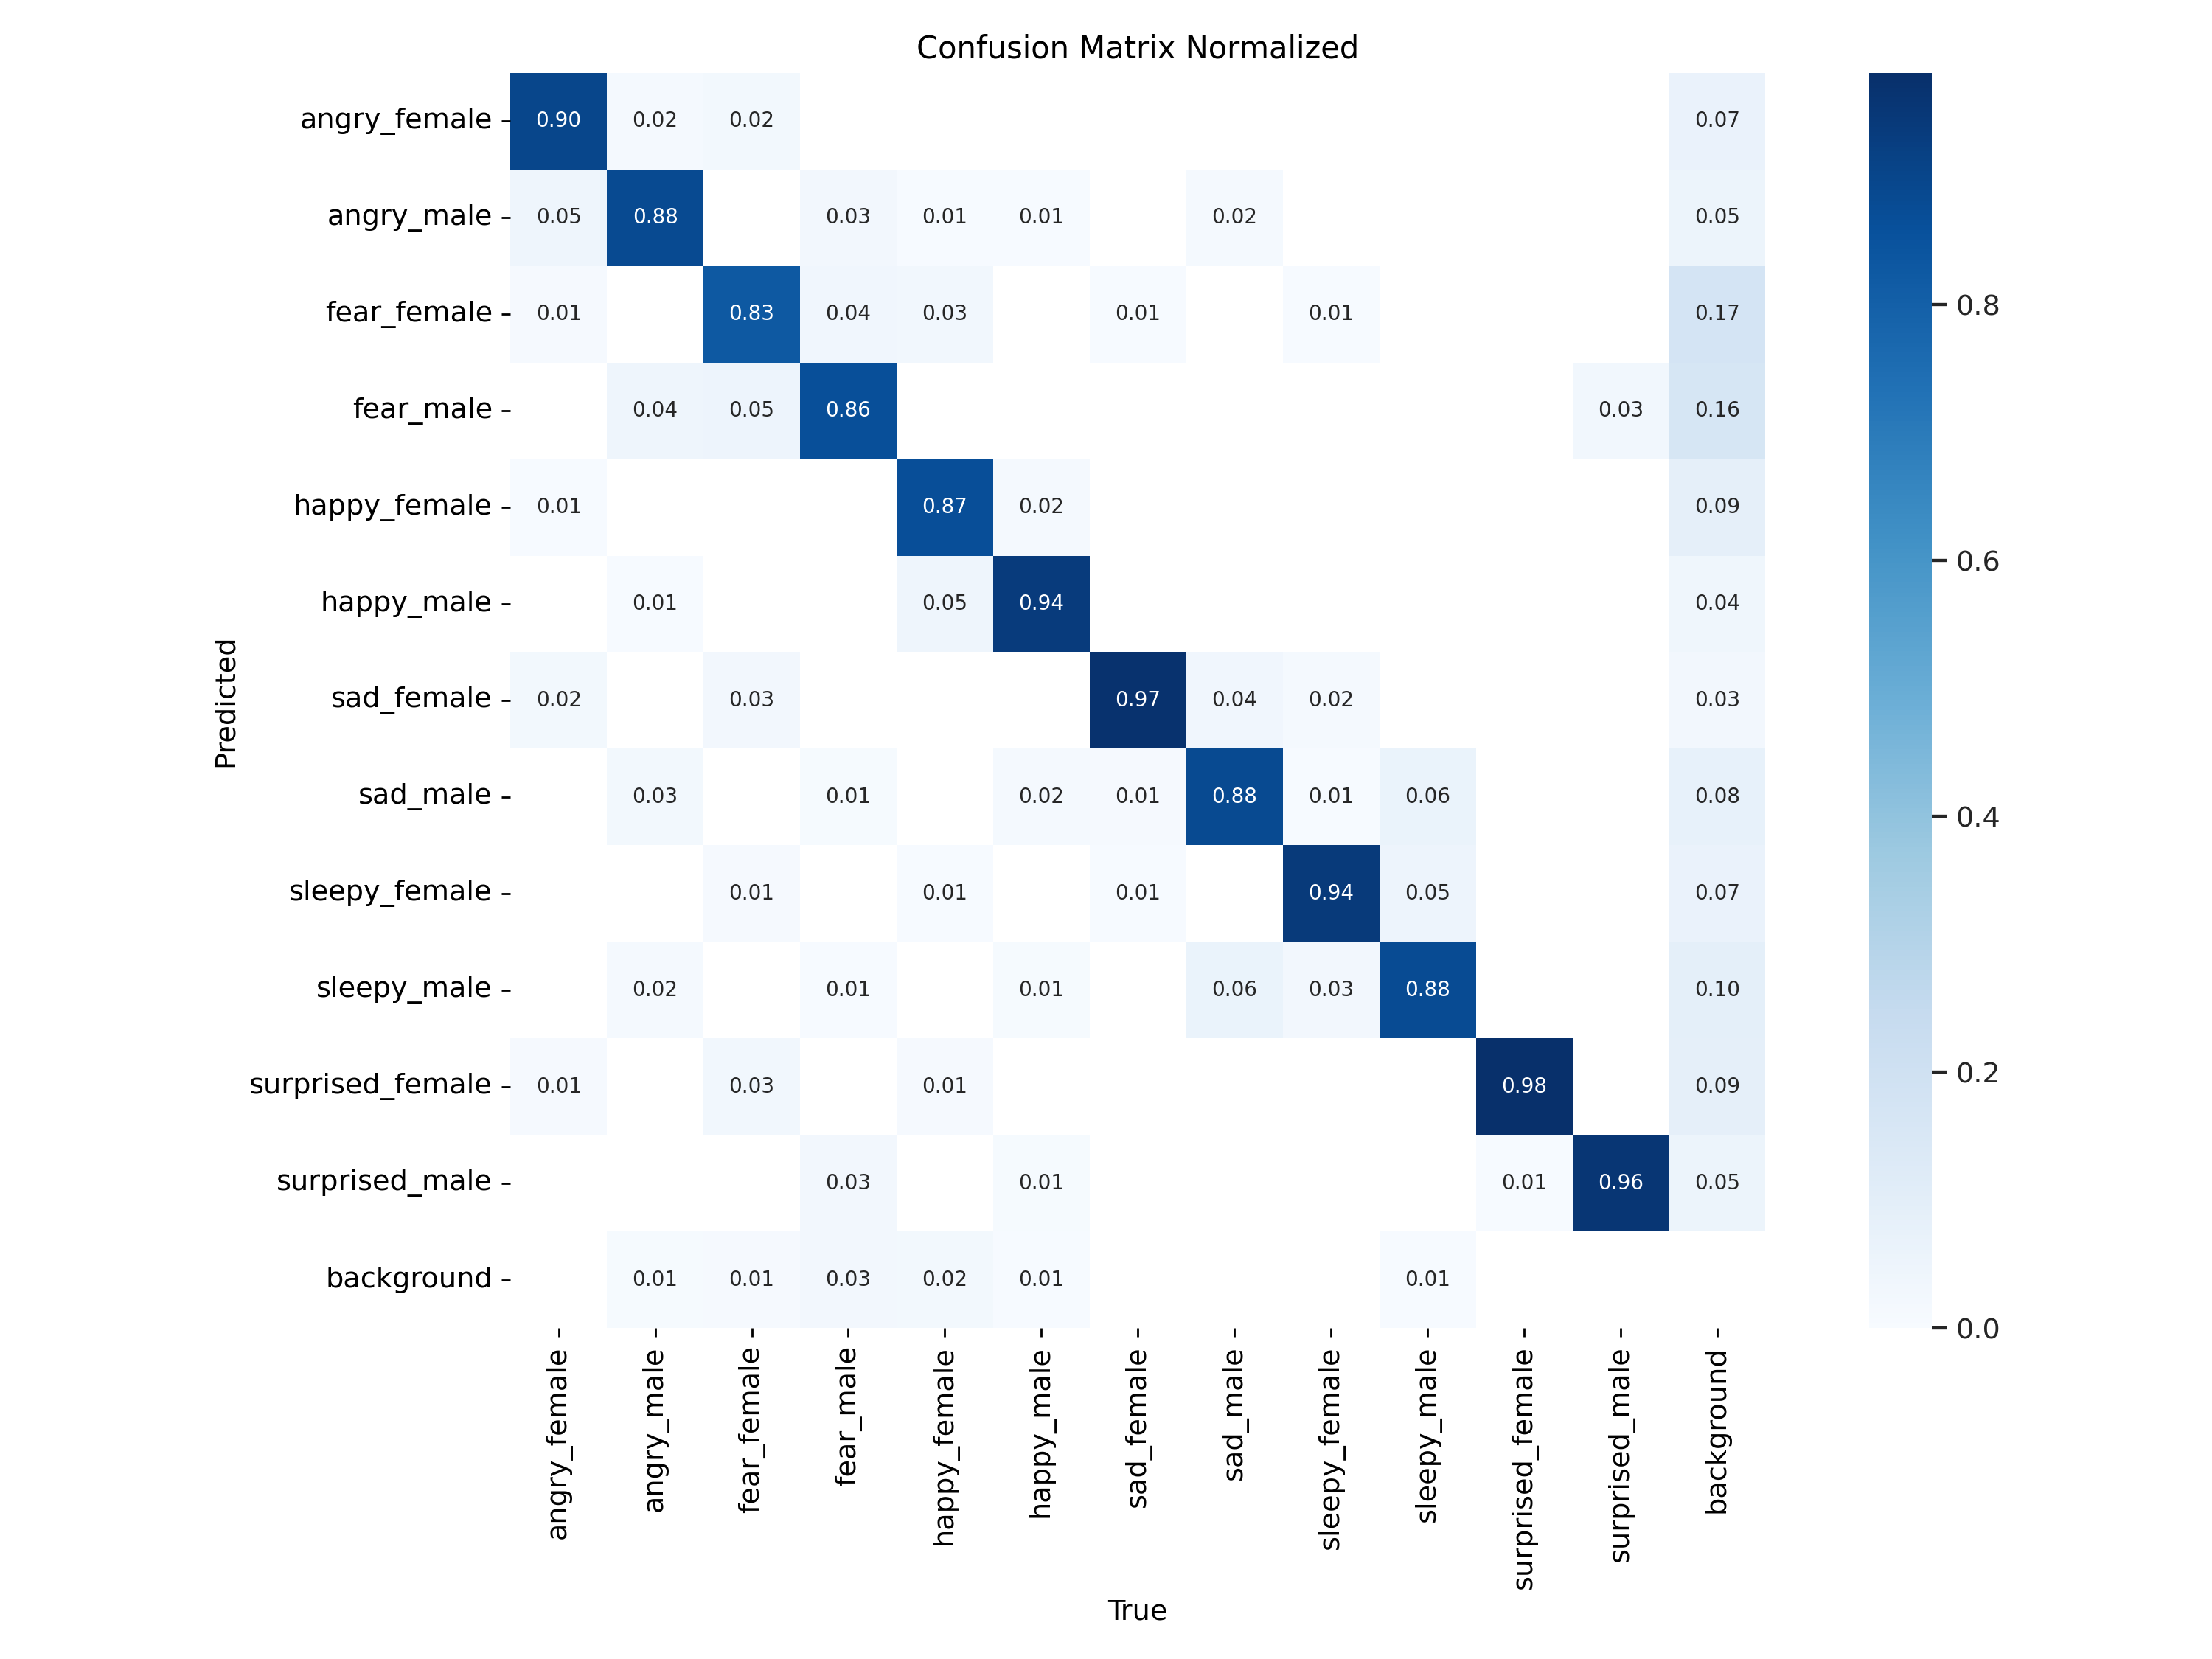

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/confusion_matrix_normalized.png', width=600)

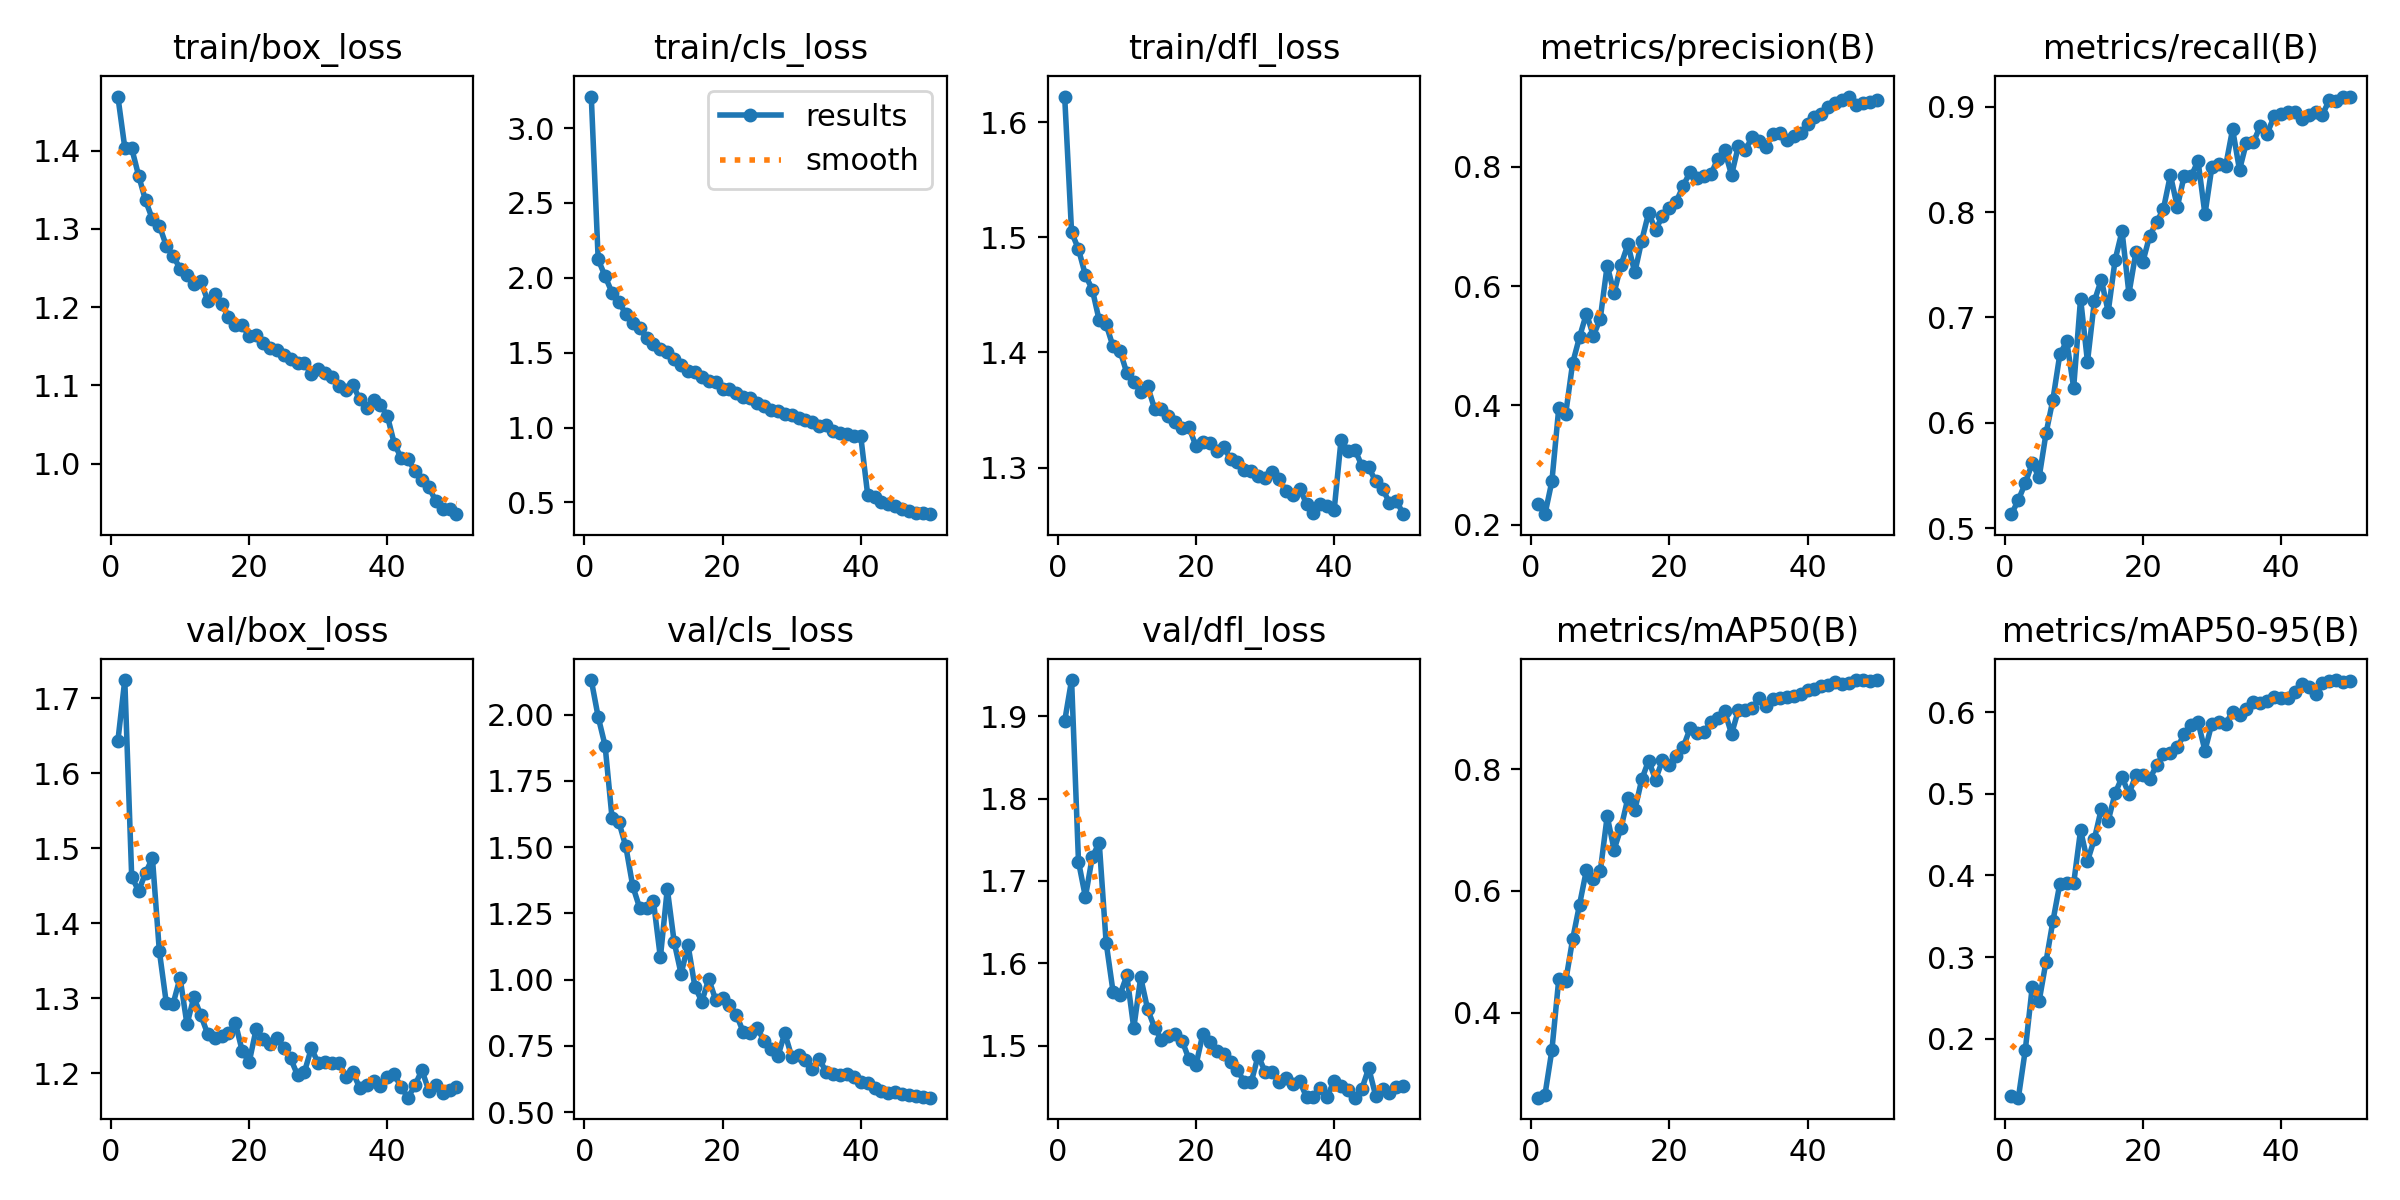

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/results.png', width=600)

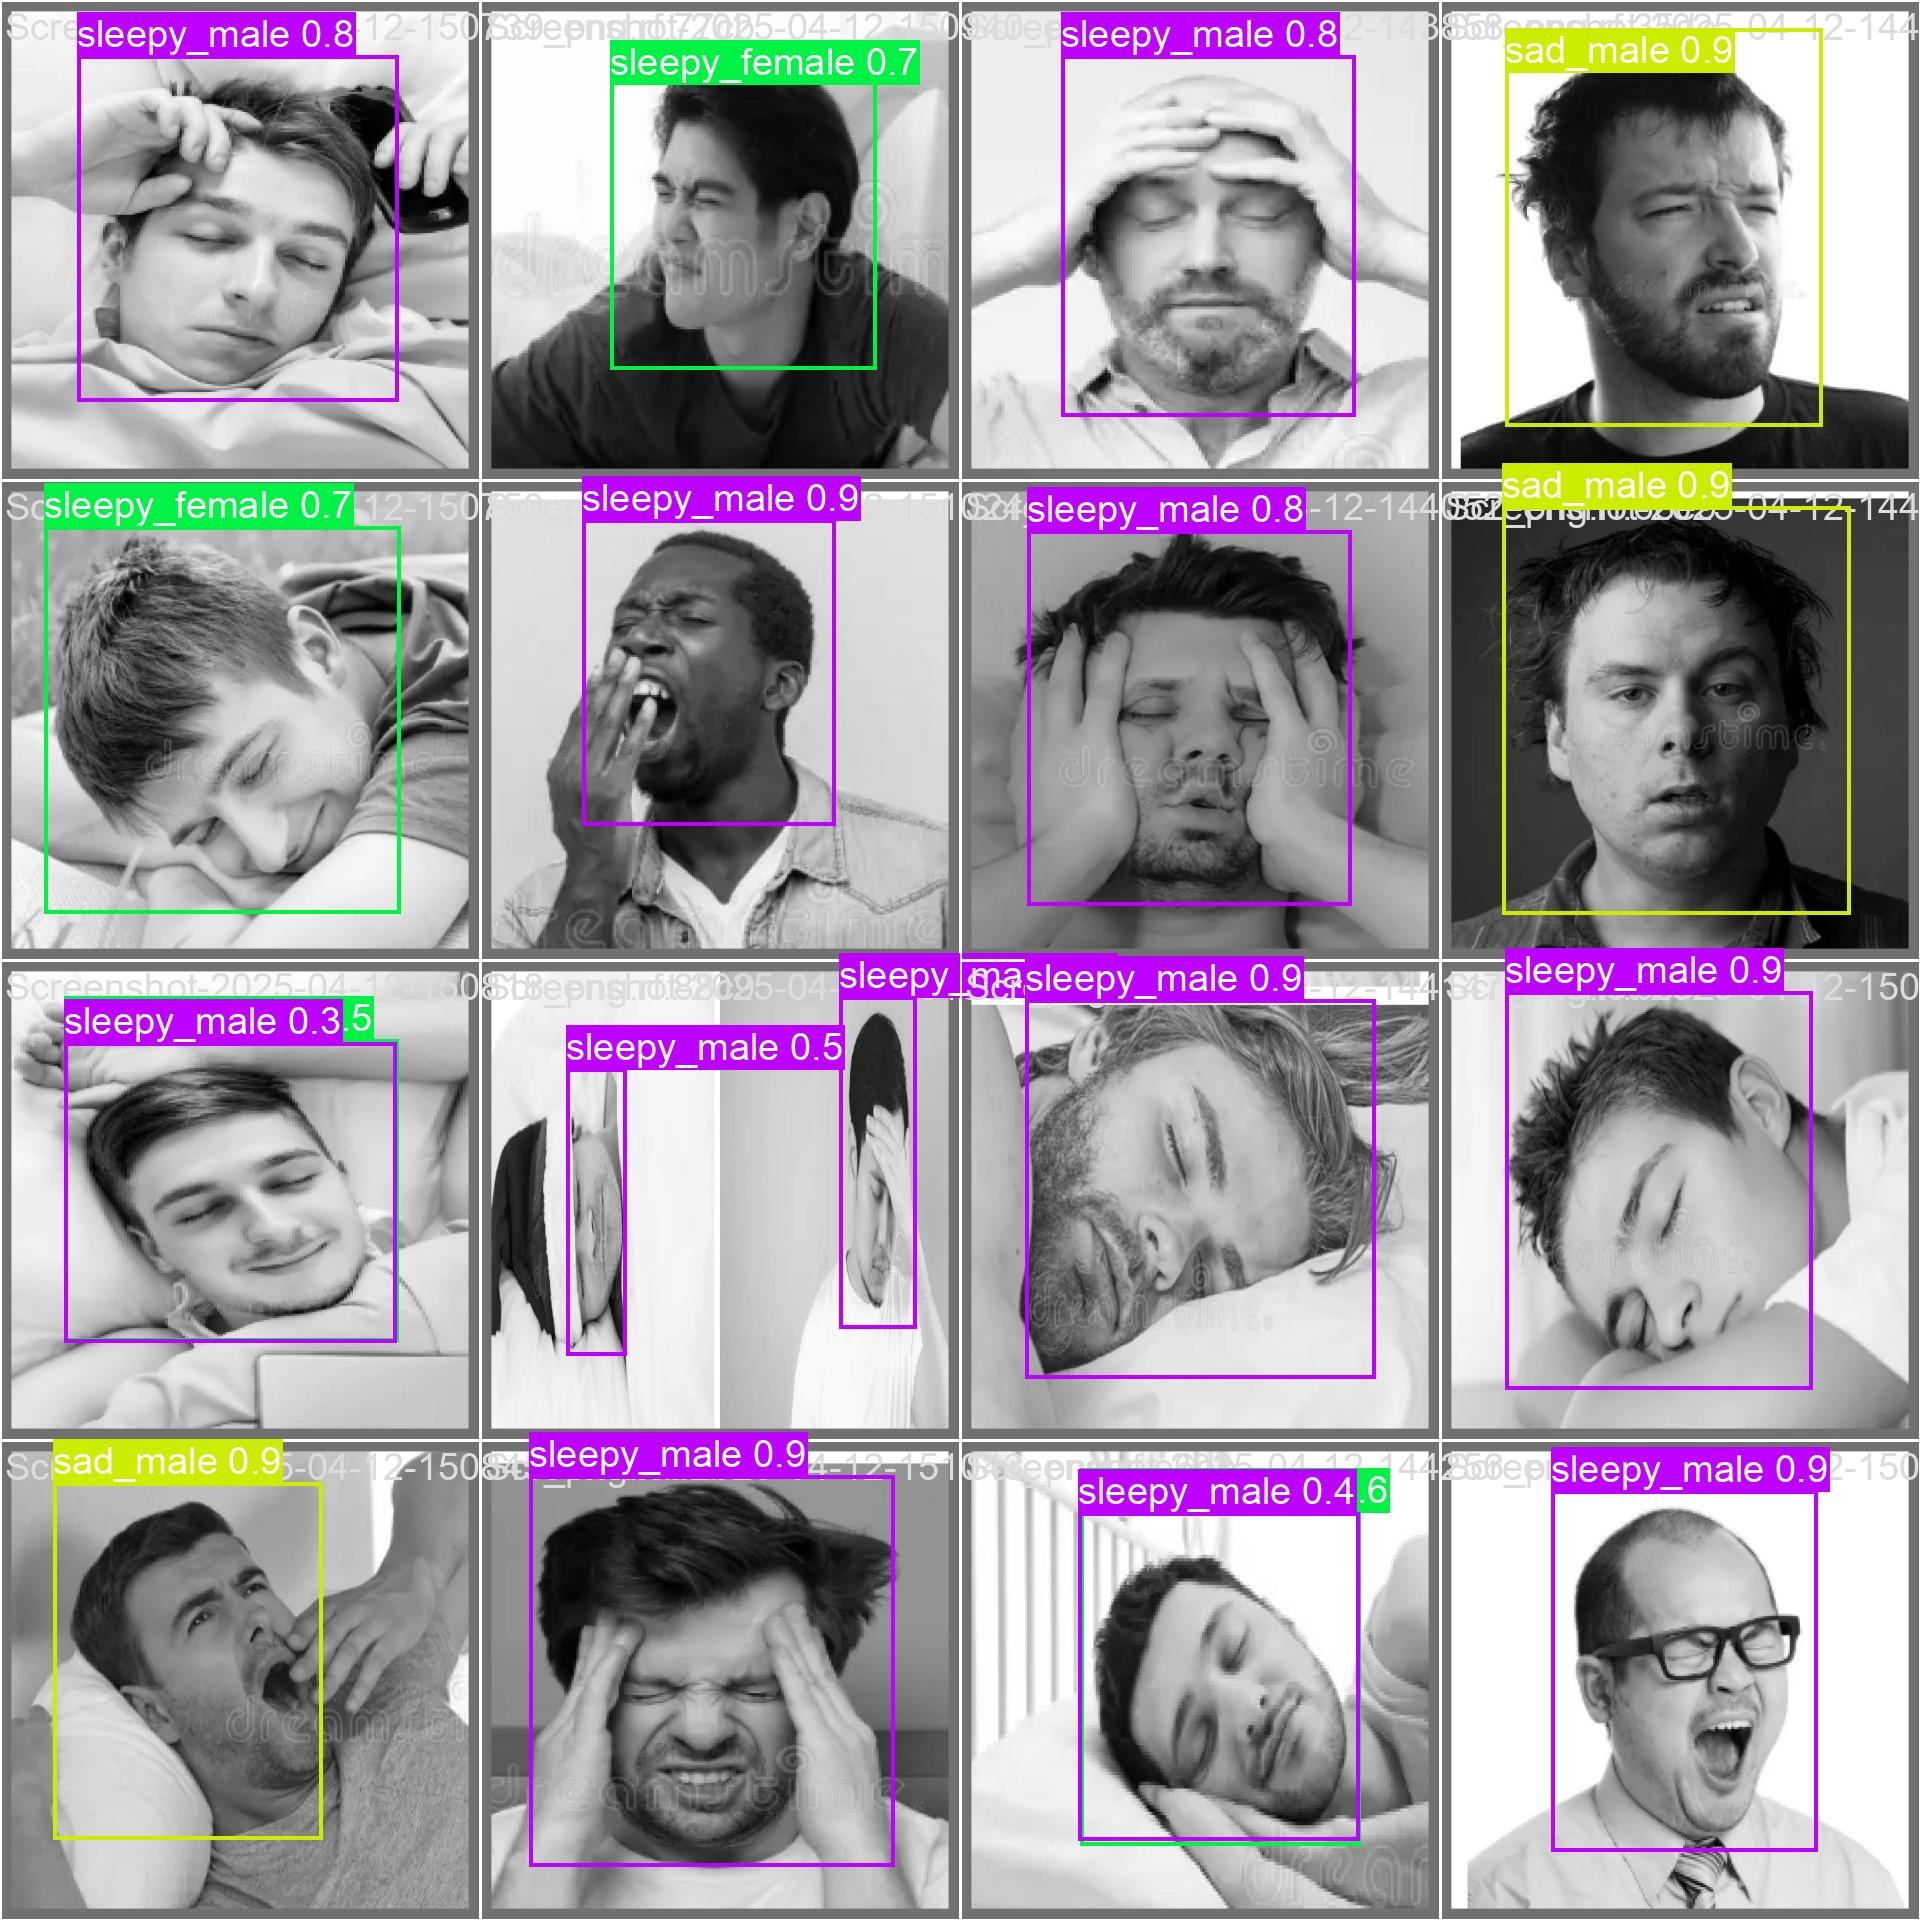

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

## Validate fine-tuned model

In [ ]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data=/content/datasets/FER2025/data.yaml

Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 238 layers, 9,417,444 parameters, 0 gradients, 21.3 GFLOPs
val: Scanning /content/datasets/FER2025/valid/labels.cache... 1478 images, 0 backgrounds, 0 corrupt: 100% 1478/1478 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 93/93 [00:22<00:00,  4.20it/s]
                   all       1478       2247      0.907      0.905      0.946       0.64
          angry_female        120        168      0.939      0.924      0.977      0.653
            angry_male        151        187      0.913      0.893      0.952      0.671
           fear_female        147        206      0.845      0.806      0.875       0.53
             fear_male        143        185      0.824      0.836      0.855      0.501
          happy_female        119        161      0.938       0.87      0.961      0.622
            happy_male        131        

## Inference with custom model

In [ ]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source=/content/datasets/FER2025/test/images save=True

Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 238 layers, 9,417,444 parameters, 0 gradients, 21.3 GFLOPs

image 1/737 /content/datasets/FER2025/test/images/Screenshot-2025-03-27-194913_png.rf.5a00d7577541a62d0e34f86c09220c01.jpg: 640x640 1 fear_female, 1 fear_male, 15.6ms
image 2/737 /content/datasets/FER2025/test/images/Screenshot-2025-03-27-194940_bright_png.rf.f40d5be04f45883332d51cc50e255c84.jpg: 640x640 2 fear_males, 15.6ms
image 3/737 /content/datasets/FER2025/test/images/Screenshot-2025-03-27-195005_contrast_png.rf.2ef3b47eeeefd883daf3051912f3dea8.jpg: 640x640 1 fear_male, 15.6ms
image 4/737 /content/datasets/FER2025/test/images/Screenshot-2025-03-27-195222_png.rf.636c457ca3fc0066da5f5569d8089b7a.jpg: 640x640 15 fear_females, 17 fear_males, 15.6ms
image 5/737 /content/datasets/FER2025/test/images/Screenshot-2025-03-27-195236_bright_png.rf.165f983f19c3444db6fb787d5e59b08a.jpg: 640x640 1 fear_female, 15.6ms
image 6/737 /

**NOTE:** Let's take a look at few results.

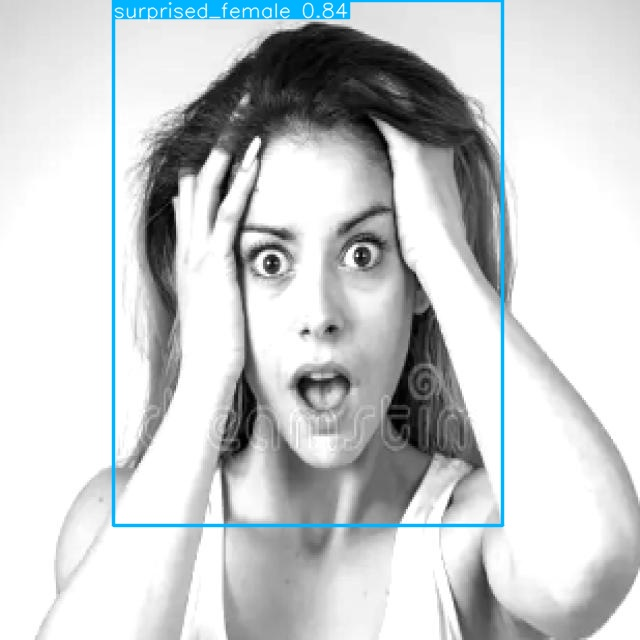

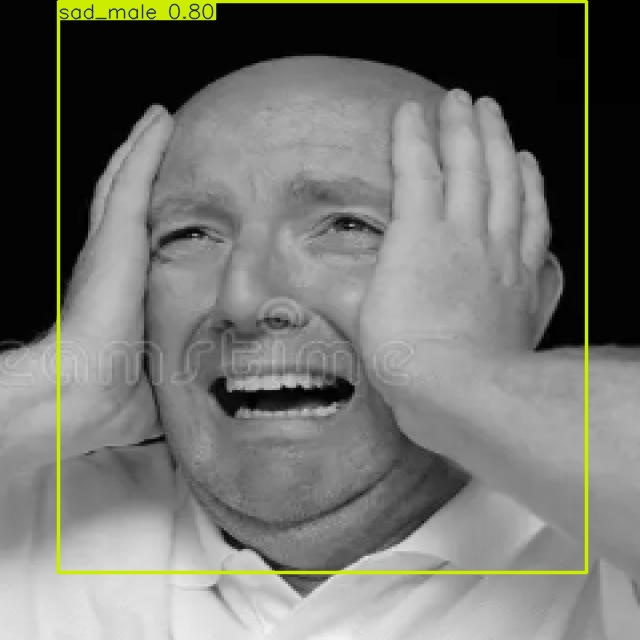

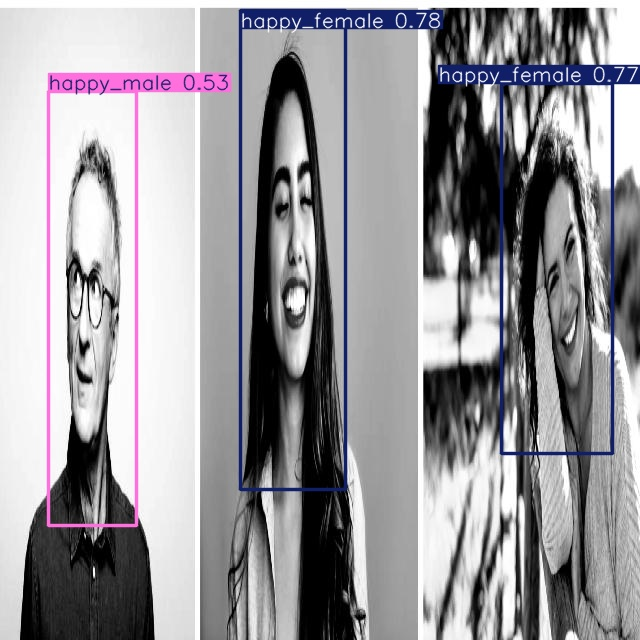

In [ ]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")


image 1/1 /content/runs/detect/predict2/Screenshot-2025-06-04-154410_aug2_jpg.rf.21a77f3801b36e4ffb85ada458385186.jpg: 640x640 1 Compass, 1 Divider, 1 Eraser, 1 Protractor_180deg, 1 Scale_15cm, 2 Set_Square_45degs, 2 Set_Square_60degs, 2 Sharpeners, 18.6ms
Speed: 2.8ms preprocess, 18.6ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/runs/detect/predict2/Screenshot-2025-06-04-153836_aug6_jpg.rf.22254f1209c9e0eee04eecf897f1a488.jpg: 640x640 1 Compass, 1 Divider, 1 Eraser, 1 Protractor_180deg, 1 Scale_15cm, 3 Set_Square_45degs, 1 Set_Square_60deg, 15.7ms
Speed: 2.5ms preprocess, 15.7ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/runs/detect/predict2/Screenshot-2025-06-04-154037_aug17_jpg.rf.a628d8f982195ea7af017ebdecd7d0ba.jpg: 640x640 1 Divider, 1 Eraser, 1 Pencil, 1 Sharpener, 15.7ms
Speed: 2.6ms preprocess, 15.7ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/runs/det

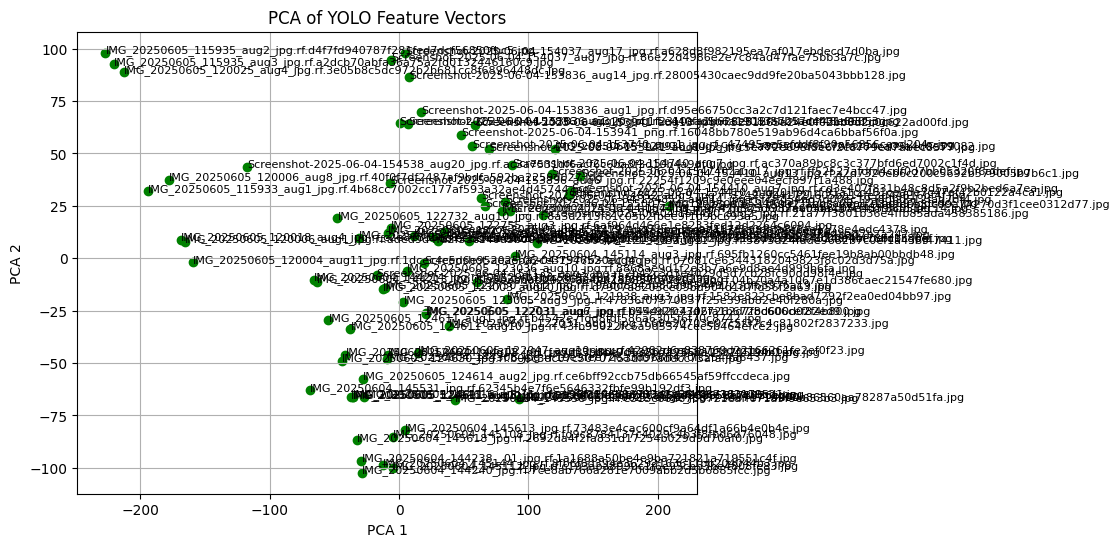

In [ ]:
# Step 1: Install and import required libraries
!pip install -q ultralytics
from ultralytics import YOLO
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Step 2: Load the trained model
model_path = '/content/runs/detect/train/weights/best.pt'  # Update path if needed
model = YOLO(model_path)

# Step 3: Load images
image_dir = '/content/runs/detect/predict2'
images = [os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# Step 4: Extract YOLO feature vectors
feature_vectors = []
image_names = []

for img_path in images:
    results = model(img_path)[0]  # ✅ No size argument!
    boxes = results.boxes

    if boxes and boxes.xywh is not None and len(boxes.xywh) > 0:
        coords = boxes.xywh.cpu().numpy()
        vector = coords.mean(axis=0).tolist()
    else:
        vector = [0, 0, 0, 0]  # Fallback if no detections

    feature_vectors.append(vector)
    image_names.append(os.path.basename(img_path))

# Step 5: PCA
X = np.array(feature_vectors)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Step 6: Plot PCA
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='green')
for i, name in enumerate(image_names):
    plt.annotate(name, (X_pca[i, 0], X_pca[i, 1]), fontsize=8)
plt.title('PCA of YOLO Feature Vectors')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.grid(True)
plt.show()



image 1/1 /content/runs/detect/predict2/Screenshot-2025-06-04-154410_aug2_jpg.rf.21a77f3801b36e4ffb85ada458385186.jpg: 640x640 1 Compass, 1 Divider, 1 Eraser, 1 Protractor_180deg, 1 Scale_15cm, 2 Set_Square_45degs, 2 Set_Square_60degs, 2 Sharpeners, 25.7ms
Speed: 2.7ms preprocess, 25.7ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/runs/detect/predict2/Screenshot-2025-06-04-153836_aug6_jpg.rf.22254f1209c9e0eee04eecf897f1a488.jpg: 640x640 1 Compass, 1 Divider, 1 Eraser, 1 Protractor_180deg, 1 Scale_15cm, 3 Set_Square_45degs, 1 Set_Square_60deg, 18.3ms
Speed: 2.5ms preprocess, 18.3ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/runs/detect/predict2/Screenshot-2025-06-04-154037_aug17_jpg.rf.a628d8f982195ea7af017ebdecd7d0ba.jpg: 640x640 1 Divider, 1 Eraser, 1 Pencil, 1 Sharpener, 16.0ms
Speed: 2.5ms preprocess, 16.0ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/runs/det

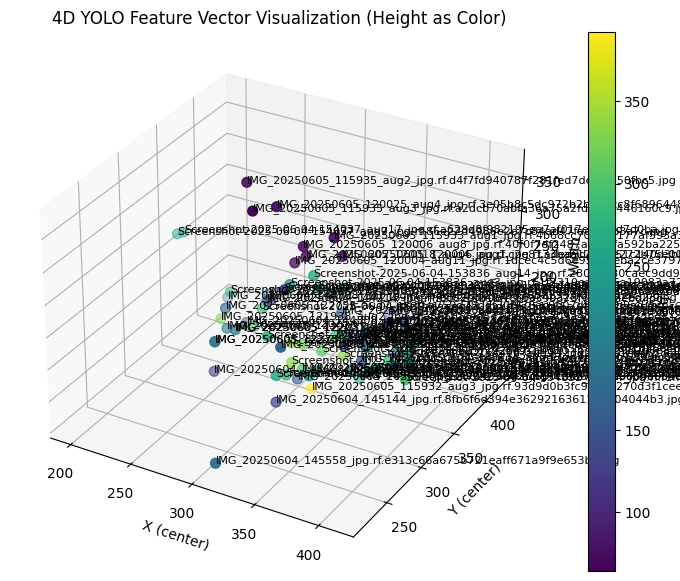

In [ ]:
# Step 1: Install and import libraries
!pip install -q ultralytics
from ultralytics import YOLO
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # For 3D plotting
from PIL import Image

# Step 2: Load the trained YOLO model
model_path = '/content/runs/detect/train/weights/best.pt'  # Update if needed
model = YOLO(model_path)

# Step 3: Set image directory
image_dir = '/content/runs/detect/predict2'  # Folder with test images
images = [os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# Step 4: Extract 4D feature vectors
feature_vectors = []
image_names = []

for img_path in images:
    results = model(img_path)[0]
    boxes = results.boxes

    if boxes and boxes.xywh is not None and len(boxes.xywh) > 0:
        coords = boxes.xywh.cpu().numpy()
        vector = coords.mean(axis=0).tolist()  # Average [x, y, w, h]
    else:
        vector = [0, 0, 0, 0]  # Default if no detection

    feature_vectors.append(vector)
    image_names.append(os.path.basename(img_path))

# Step 5: 4D Visualization - 3D scatter + height as color
X = np.array(feature_vectors)
x, y, w, h = X[:, 0], X[:, 1], X[:, 2], X[:, 3]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(x, y, w, c=h, cmap='viridis', s=50)

# Annotate with image names
for i, name in enumerate(image_names):
    ax.text(x[i], y[i], w[i], name, size=8)

# Labels and colorbar
ax.set_xlabel('X (center)')
ax.set_ylabel('Y (center)')
ax.set_zlabel('Width')
plt.title('4D YOLO Feature Vector Visualization (Height as Color)')
plt.colorbar(sc, label='Height')
plt.show()


In [ ]:
from google.colab import files
import shutil

# Replace 'your_folder' with the folder you want to download
folder_name = "/content/runs/detect"
zip_name = f"{folder_name}.zip"

# Zip the folder
shutil.make_archive(folder_name, 'zip', folder_name)

# Download the zipped folder
files.download(zip_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>